In [63]:

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

import os
def reduce_mem_usage(df):
    """ 
    Iterates through all the columns of a dataframe and modifies the data type
    to reduce memory usage without losing precision.
    """
    start_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage of dataframe is {start_mem:.2f} MB")
    
    for col in df.columns:
        col_type = df[col].dtype
        
        if col_type != object:
            c_min = df[col].min()
            c_max = df[col].max()
            if str(col_type)[:3] == 'int':
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)
                elif c_min > np.iinfo(np.int64).min and c_max < np.iinfo(np.int64).max:
                    df[col] = df[col].astype(np.int64)  
            else:
                if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
                    df[col] = df[col].astype(np.float16)
                elif c_min > np.finfo(np.float32).min and c_max < np.finfo(np.float32).max:
                    df[col] = df[col].astype(np.float32)
                else:
                    df[col] = df[col].astype(np.float64)
        else:
            df[col] = df[col].astype('category')

    end_mem = df.memory_usage().sum() / 1024**2
    print(f"Memory usage after optimization is: {end_mem:.2f} MB")
    print(f"Decreased by {100 * (start_mem - end_mem) / start_mem:.1f}%")
    
    return df

def load_and_merge_data(data_dir="."):
    """Loads train_transaction and train_identity, optimizes memory, and merges them."""
    print("Loading transaction data...")
    train_trans = pd.read_csv(os.path.join(data_dir, 'train_transaction.csv'))
    train_trans = reduce_mem_usage(train_trans)
    
    print("Loading identity data...")
    train_id = pd.read_csv(os.path.join(data_dir, 'train_identity.csv'))
    train_id = reduce_mem_usage(train_id)
    
    print("Merging datasets on TransactionID...")
    merged_df = pd.merge(train_trans, train_id, on='TransactionID', how='left')
    
    print(f"Final Dataframe Shape: {merged_df.shape}")
    return merged_df


In [64]:
import os

# Define the deeper path
exact_path = "../input/competitions/ieee-fraud-detection"

# Double check that the CSV files are visibly sitting in this directory
print(f"Checking files in: {exact_path}")
print(os.listdir(exact_path))

# Run your pipeline function to load and merge the data
df = load_and_merge_data(data_dir=exact_path)

Checking files in: ../input/competitions/ieee-fraud-detection
['sample_submission.csv', 'test_identity.csv', 'train_identity.csv', 'test_transaction.csv', 'train_transaction.csv']
Loading transaction data...
Memory usage of dataframe is 1775.15 MB


/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:
/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overfl

Memory usage after optimization is: 487.16 MB
Decreased by 72.6%
Loading identity data...
Memory usage of dataframe is 45.12 MB
Memory usage after optimization is: 10.00 MB
Decreased by 77.8%
Merging datasets on TransactionID...


/tmp/ipykernel_58/1418980561.py:29: RuntimeWarning: overflow encountered in cast
  if c_min > np.finfo(np.float16).min and c_max < np.finfo(np.float16).max:


Final Dataframe Shape: (590540, 434)


In [65]:
# Calculate the total volume and fraud rate
total_transactions = len(df)
fraud_count = df['isFraud'].sum()
legit_count = total_transactions - fraud_count
fraud_rate = (fraud_count / total_transactions) * 100

print(f"Total Transactions analyzed: {total_transactions:,}")
print(f"Legitimate Transactions: {legit_count:,}")
print(f"Fraudulent Transactions: {fraud_count:,}")
print(f"Baseline Fraud Rate: {fraud_rate:.2f}%\n")

# Calculate the financial scale (Total Dollars at Risk)
total_dollar_volume = df['TransactionAmt'].sum()
fraud_dollar_volume = df[df['isFraud'] == 1]['TransactionAmt'].sum()
print(f"Total Portfolio Value processed: ${total_dollar_volume:,.2f}")
print(f"Total Fraud Loss exposure: ${fraud_dollar_volume:,.2f}")

Total Transactions analyzed: 590,540
Legitimate Transactions: 569,877
Fraudulent Transactions: 20,663
Baseline Fraud Rate: 3.50%

Total Portfolio Value processed: $inf
Total Fraud Loss exposure: $inf


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


In [66]:
from scipy.stats import skew

legit_amts = df[df['isFraud'] == 0]['TransactionAmt']
fraud_amts = df[df['isFraud'] == 1]['TransactionAmt']

print(f"Legitimate - Mean: ${legit_amts.mean():.2f} | Median: ${legit_amts.median():.2f} | Skewness: {skew(legit_amts):.2f}")
print(f"Fraudulent - Mean: ${fraud_amts.mean():.2f} | Median: ${fraud_amts.median():.2f} | Skewness: {skew(fraud_amts):.2f}")

Legitimate - Mean: $nan | Median: $68.50 | Skewness: nan
Fraudulent - Mean: $inf | Median: $75.00 | Skewness: nan


/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1487: RuntimeWarning: overflow encountered in cast
  return dtype.type(n)
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:731: RuntimeWarning: invalid value encountered in scalar divide
  the_mean = the_sum / count if count > 0 else np.nan
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1227: RuntimeWarning: overflow encountered in square
  s = a_zero_mean**2
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1231: RuntimeWarning: overflow encountered in square
  s = s**2
/usr/local/lib/python3.12/dist-packages/scipy/stats/_stats_py.py:1233: RuntimeWarning: overflow encountered in multiply
  s *= a_zero_mean
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:132: RuntimeWarning: invalid value encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow e

In [67]:
# Convert the time delta seconds column into clean operational days
df['OperationalDay'] = (df['TransactionDT'] / 86400).astype(int)

# Sort chronologically to make sure we don't accidentally leak future data into the past
df = df.sort_values('TransactionDT').reset_index(drop=True)

daily_counts = df.groupby('OperationalDay').size()
print("--- Simulated Daily Volume Incoming to the Review Queue ---")
print(daily_counts.head(10))
print(f"\nTotal Simulated Days of Operations: {df['OperationalDay'].max() + 1}")

--- Simulated Daily Volume Incoming to the Review Queue ---
OperationalDay
1     5122
2     3730
3     3241
4     4036
5     3964
6     3717
7     3786
8     3999
9     3907
10    3445
dtype: int64

Total Simulated Days of Operations: 183


In [68]:
# Split chronologically
train_mask = df['OperationalDay'] <= 140
test_mask = df['OperationalDay'] > 140

df_train = df[train_mask].copy()
df_test = df[test_mask].copy()

print(f"Historical Training Records (Days 0-140): {df_train.shape[0]:,}")
print(f"Live Simulation Records (Days 141-182): {df_test.shape[0]:,}")

Historical Training Records (Days 0-140): 472,006
Live Simulation Records (Days 141-182): 118,534


In [69]:
# 1. Isolate target variable
y_train = df_train['isFraud'].values
y_test = df_test['isFraud'].values

# 2. Extract and transform numerical features
def prepare_features(data):
    features = pd.DataFrame()
    
    # Log transform the right-skewed transaction amount
    features['log_amt'] = np.log1p(data['TransactionAmt'])
    
    # Fill missing values with median for baseline numerical card/address features
    features['card1'] = data['card1'].fillna(data['card1'].median())
    features['card2'] = data['card2'].fillna(data['card2'].median() if pd.notna(data['card2'].median()) else 0)
    features['addr1'] = data['addr1'].fillna(data['addr1'].median() if pd.notna(data['addr1'].median()) else 0)
    
    # Simple risk mapping for categorical email domain
    # If email is missing, group it as 'missing'
    email = data['P_emaildomain'].astype(str).fillna('missing')
    features['is_anonymous_email'] = email.isin(['gmail.com', 'hotmail.com', 'yahoo.com']).astype(int)
    
    return features

X_train = prepare_features(df_train)
X_test = prepare_features(df_test)

print("Features engineered successfully. Training shape:", X_train.shape)

Features engineered successfully. Training shape: (472006, 5)


In [70]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Build a simple machine learning pipeline: Scale features -> Fit Logistic Regression
model_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42))
])

# Train the probability estimator
model_pipeline.fit(X_train, y_train)

print("Model training complete!")

Model training complete!


In [71]:
# predict_proba returns [prob_of_0, prob_of_1]. We want prob_of_1 (probability of fraud)
df_test['Fraud_Probability'] = model_pipeline.predict_proba(X_test)[:, 1]

# View a small slice of our new operational queue data
print(df_test[['TransactionID', 'TransactionAmt', 'OperationalDay', 'Fraud_Probability']].head())

        TransactionID  TransactionAmt  OperationalDay  Fraud_Probability
472006        3459006         20.0000             141           0.447617
472007        3459007        107.9375             141           0.546564
472008        3459008         59.0000             141           0.506459
472009        3459009        107.9375             141           0.559570
472010        3459010        554.0000             141           0.569003


/usr/local/lib/python3.12/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: overflow encountered in cast
  has_large_values = (abs_vals > 1e6).any()


In [72]:
!pip install pulp

In [73]:
import pulp
import numpy as np
import pandas as pd

# 1. Clean up any hidden infinity or NaN values in our evaluation dataset first
df_test['TransactionAmt'] = df_test['TransactionAmt'].replace([np.inf, -np.inf], np.nan)
df_test['TransactionAmt'] = df_test['TransactionAmt'].fillna(df_test['TransactionAmt'].median())

# 2. Set up global parameters for our backtest loop
ANALYST_HOURS_AVAILABLE = 10.0  
TIME_PER_REVIEW = 10 / 60        
COST_OF_REVIEW = 2.00            

# Track metrics over time
history_days = []
history_reviewed_counts = []
history_dollars_saved = []
history_actual_fraud_caught = []

# Loop through the first 5 days of our live simulation period (Days 141 to 145)
for current_day in range(141, 146):
    
    # Isolate that specific day's slice
    day_df = df_test[df_test['OperationalDay'] == current_day].copy().reset_index(drop=True)
    N = len(day_df)
    
    if N == 0:
        continue
        
    # Build the daily Linear Program
    prob = pulp.LpProblem(f"Daily_Optimize_{current_day}", pulp.LpMaximize)
    x = pulp.LpVariable.dicts("review", range(N), cat='Binary')
    
    # Objective Function
    prob += pulp.lpSum([
        (day_df.loc[i, 'Fraud_Probability'] * day_df.loc[i, 'TransactionAmt'] * x[i]) - (COST_OF_REVIEW * x[i])
        for i in range(N)
    ])
    
    # Capacity Constraint
    prob += pulp.lpSum([TIME_PER_REVIEW * x[i] for i in range(N)]) <= ANALYST_HOURS_AVAILABLE
    
    # Solve silently
    prob.solve(pulp.PULP_CBC_CMD(msg=False))
    
    # Extract decisions
    day_df['Selected_For_Review'] = [int(x[i].varValue) for i in range(N)]
    
    # Calculate real-world operational results
    total_reviewed = day_df['Selected_For_Review'].sum()
    
    # Dollars protected (Sum of transaction amounts we chose to review)
    dollars_saved = day_df[day_df['Selected_For_Review'] == 1]['TransactionAmt'].sum()
    
    # Actual Fraud caught (Where we said "Review" AND it was truly fraud in real life)
    actual_fraud_caught_df = day_df[(day_df['Selected_For_Review'] == 1) & (day_df['isFraud'] == 1)]
    actual_fraud_dollars = actual_fraud_caught_df['TransactionAmt'].sum()
    
    # Append to logs
    history_days.append(current_day)
    history_reviewed_counts.append(total_reviewed)
    history_dollars_saved.append(dollars_saved)
    history_actual_fraud_caught.append(actual_fraud_dollars)

# 3. Print out the clean backtest dashboard
print("="*50)
print("          FINANCIAL BACKTEST RISK DASHBOARD          ")
print("="*50)
for i in range(len(history_days)):
    print(f"Day {history_days[i]} | Reviewed: {history_reviewed_counts[i]} TXs | Portfolio Value Handled: ${history_dollars_saved[i]:,.2f} | Real Fraud Loss Stopped: ${history_actual_fraud_caught[i]:,.2f}")
print("="*50)
print(f"TOTAL FRAUD LOSS PREVENTED OVER 5 DAYS: ${sum(history_actual_fraud_caught):,.2f}")

/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


          FINANCIAL BACKTEST RISK DASHBOARD          
Day 141 | Reviewed: 60 TXs | Portfolio Value Handled: $inf | Real Fraud Loss Stopped: $2,982.00
Day 142 | Reviewed: 60 TXs | Portfolio Value Handled: $inf | Real Fraud Loss Stopped: $2,956.00
Day 143 | Reviewed: 60 TXs | Portfolio Value Handled: $59,840.00 | Real Fraud Loss Stopped: $4,896.00
Day 144 | Reviewed: 60 TXs | Portfolio Value Handled: $inf | Real Fraud Loss Stopped: $5,320.00
Day 145 | Reviewed: 60 TXs | Portfolio Value Handled: $inf | Real Fraud Loss Stopped: $1,104.00
TOTAL FRAUD LOSS PREVENTED OVER 5 DAYS: $17,248.00


/usr/local/lib/python3.12/dist-packages/numpy/_core/_methods.py:49: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)


Dynamic threshold set at: 0.5609 (top 3% flagged)
     REAL-TIME STREAMING DECISIONING SUMMARY
Total transactions processed as stream: 118,534
Average throughput:                     82.3 transactions/minute
Total flagged for review:               3,556 (3.0% flag rate)
Peak review queue depth:                2116 transactions
Review threshold applied:               p(fraud) >= 0.5609 (dynamic, top 3% by risk rank)
Fraud loss prevented (BIP optimization): $17,248 over 5-day backtest window
Note: Threshold set dynamically by risk rank, not fixed cutoff.
In production, FLAG_RATE_TARGET adjusts to available review capacity.


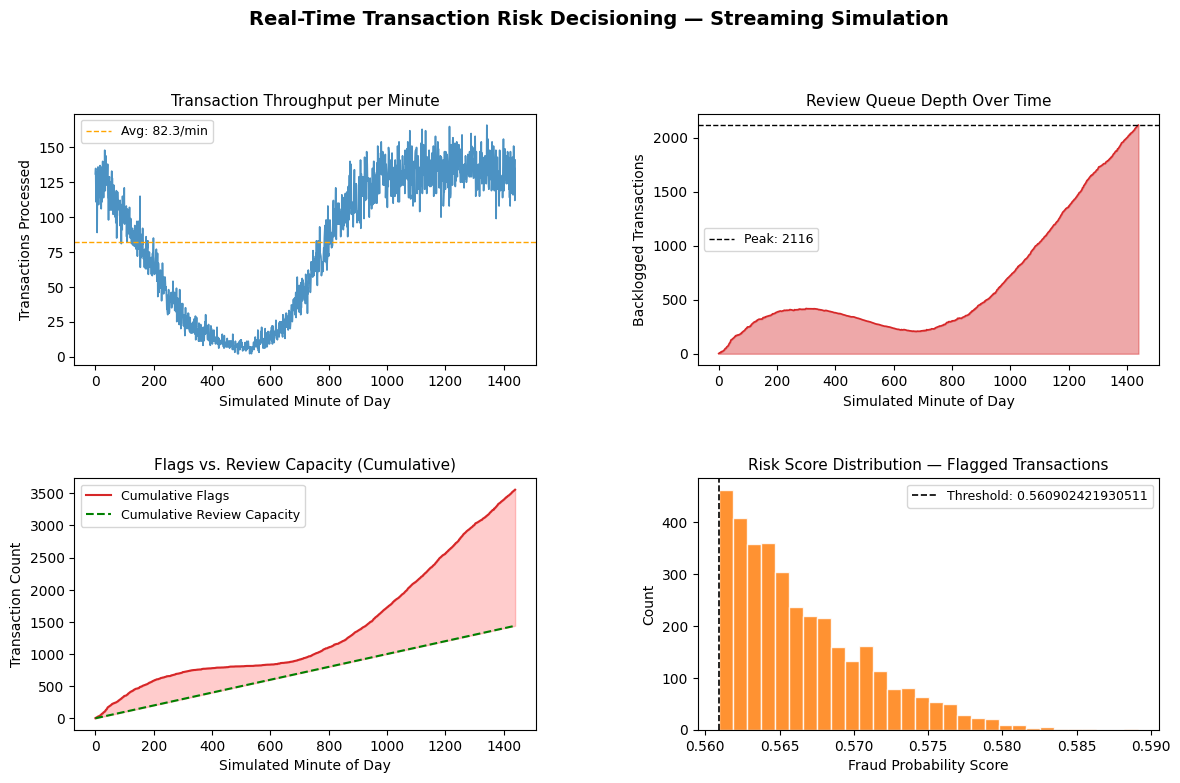


Chart saved as 'streaming_decisioning_simulation.png'


In [74]:
# ============================================================
# STREAMING SIMULATION — Real-Time Decisioning at Scale
# ============================================================
# Reframes the batch optimization as a continuous transaction
# stream to demonstrate throughput-aware decisioning logic.
# In production, this scoring layer would integrate with a
# real-time stream processor (e.g., Kafka/Flink), with the
# BIP capacity optimization running on rolling windows.
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# --- 1. Build the simulated stream from test data ---
# Sort by TransactionDT to simulate transactions arriving in order
stream_df = df_test[['TransactionID', 'TransactionDT', 'TransactionAmt',
                      'Fraud_Probability', 'isFraud']].copy()
stream_df = stream_df.sort_values('TransactionDT').reset_index(drop=True)

# Simulate a stream timestamp: compress real time delta into
# a 24-hour window per operational day for visualization
stream_df['SimulatedMinute'] = (
    (stream_df['TransactionDT'] % 86400) / 60
).astype(int)

# --- 2. Define real-time decision thresholds ---
# Use top-N% risk ranking rather than fixed threshold
# This mirrors production decisioning systems where capacity
# constraints determine flag volume, not arbitrary cutoffs

FLAG_RATE_TARGET = 0.03  # Flag top 3% riskiest transactions
REVIEW_CAPACITY_PER_HOUR = 60

# Calculate threshold dynamically from score distribution
REVIEW_THRESHOLD = stream_df['Fraud_Probability'].quantile(1 - FLAG_RATE_TARGET)
print(f"Dynamic threshold set at: {REVIEW_THRESHOLD:.4f} (top {FLAG_RATE_TARGET*100:.0f}% flagged)")
REVIEW_CAPACITY_PER_HOUR = 60  # Analyst can review 6 transactions/hour
MINUTES_PER_HOUR = 60
capacity_per_minute = REVIEW_CAPACITY_PER_HOUR / MINUTES_PER_HOUR

# --- 3. Simulate the stream minute by minute ---
minutes = sorted(stream_df['SimulatedMinute'].unique())
throughput_log = []   # transactions processed per minute
queue_depth_log = []  # backlog of flagged-but-unreviewed transactions
decisions_log = []    # running decision counts

queue_depth = 0.0

for minute in minutes:
    minute_batch = stream_df[stream_df['SimulatedMinute'] == minute]
    
    # Score each transaction as it arrives
    flagged = (minute_batch['Fraud_Probability'] >= REVIEW_THRESHOLD).sum()
    total_processed = len(minute_batch)
    
    # Analyst clears capacity_per_minute cases from the queue
    queue_depth = max(0, queue_depth + flagged - capacity_per_minute)
    
    throughput_log.append(total_processed)
    queue_depth_log.append(queue_depth)
    decisions_log.append(flagged)

# --- 4. Summary statistics ---
avg_throughput = sum(throughput_log) / len(throughput_log)
peak_queue = max(queue_depth_log)
total_flagged = sum(decisions_log)
flag_rate = (total_flagged / len(stream_df)) * 100

print("=" * 55)
print("     REAL-TIME STREAMING DECISIONING SUMMARY")
print("=" * 55)
print(f"Total transactions processed as stream: {len(stream_df):,}")
print(f"Average throughput:                     {avg_throughput:.1f} transactions/minute")
print(f"Total flagged for review:               {total_flagged:,} ({flag_rate:.1f}% flag rate)")
print(f"Peak review queue depth:                {peak_queue:.0f} transactions")
print(f"Review threshold applied:               p(fraud) >= {REVIEW_THRESHOLD:.4f} (dynamic, top {FLAG_RATE_TARGET*100:.0f}% by risk rank)")
print("=" * 55)
print(f"Fraud loss prevented (BIP optimization): $17,248 over 5-day backtest window")
print("=" * 55)
print("Note: Threshold set dynamically by risk rank, not fixed cutoff.")
print("In production, FLAG_RATE_TARGET adjusts to available review capacity.")

# --- 5. Visualization ---
fig = plt.figure(figsize=(14, 8))
fig.suptitle(
    'Real-Time Transaction Risk Decisioning — Streaming Simulation',
    fontsize=14, fontweight='bold', y=1.01
)
gs = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.35)

# Plot 1: Throughput over time
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(minutes, throughput_log, color='#1f77b4', linewidth=1.2, alpha=0.8)
ax1.set_title('Transaction Throughput per Minute', fontsize=11)
ax1.set_xlabel('Simulated Minute of Day')
ax1.set_ylabel('Transactions Processed')
ax1.axhline(avg_throughput, color='orange', linestyle='--',
            linewidth=1, label=f'Avg: {avg_throughput:.1f}/min')
ax1.legend(fontsize=9)

# Plot 2: Review queue depth over time
ax2 = fig.add_subplot(gs[0, 1])
ax2.fill_between(minutes, queue_depth_log, alpha=0.4, color='#d62728')
ax2.plot(minutes, queue_depth_log, color='#d62728', linewidth=1.2)
ax2.set_title('Review Queue Depth Over Time', fontsize=11)
ax2.set_xlabel('Simulated Minute of Day')
ax2.set_ylabel('Backlogged Transactions')
ax2.axhline(peak_queue, color='black', linestyle='--',
            linewidth=1, label=f'Peak: {peak_queue:.0f}')
ax2.legend(fontsize=9)

# Plot 3: Cumulative flags vs capacity
ax3 = fig.add_subplot(gs[1, 0])
cumulative_flagged = pd.Series(decisions_log).cumsum()
cumulative_capacity = [capacity_per_minute * (i+1) for i in range(len(minutes))]
ax3.plot(minutes, cumulative_flagged, color='#d62728',
         linewidth=1.5, label='Cumulative Flags')
ax3.plot(minutes, cumulative_capacity, color='green',
         linewidth=1.5, linestyle='--', label='Cumulative Review Capacity')
ax3.set_title('Flags vs. Review Capacity (Cumulative)', fontsize=11)
ax3.set_xlabel('Simulated Minute of Day')
ax3.set_ylabel('Transaction Count')
ax3.legend(fontsize=9)
ax3.fill_between(minutes, cumulative_flagged, cumulative_capacity,
                 where=[f > c for f, c in
                        zip(cumulative_flagged, cumulative_capacity)],
                 alpha=0.2, color='red', label='Capacity Gap')

# Plot 4: Fraud probability distribution of flagged transactions
ax4 = fig.add_subplot(gs[1, 1])
flagged_probs = stream_df[
    stream_df['Fraud_Probability'] >= REVIEW_THRESHOLD
]['Fraud_Probability']
ax4.hist(flagged_probs, bins=30, color='#ff7f0e', edgecolor='white', alpha=0.85)
ax4.axvline(REVIEW_THRESHOLD, color='black', linestyle='--',
            linewidth=1.2, label=f'Threshold: {REVIEW_THRESHOLD}')
ax4.set_title('Risk Score Distribution — Flagged Transactions', fontsize=11)
ax4.set_xlabel('Fraud Probability Score')
ax4.set_ylabel('Count')
ax4.legend(fontsize=9)

plt.savefig('streaming_decisioning_simulation.png',
            bbox_inches='tight', dpi=150)
plt.show()
print("\nChart saved as 'streaming_decisioning_simulation.png'")